In [1]:
# from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
os.chdir('PospischilEtAl2008')

!nrnivmodl

/home/fernando/Dropbox/UEPG/Intro_Neuro_Comp_Codes/one_neuron/Neuron/PospischilEtAl2008
Mod files: "./cadecay_destexhe.mod" "./HH_traub.mod" "./IL_gutnick.mod" "./IM_cortex.mod" "./IT_huguenard.mod"

 -> Compiling mod_func.cpp
 => LINKING shared library ./libnrnmech.so
Successfully created x86_64/special


In [2]:
import neuron as nrn # NEURON simulator

In [3]:
# print nrn.h
# Load external files
nrn.h.load_file("stdrun.hoc");

In [4]:
nrn.h.load_file("mosinit.hoc");

	1 
	1 
	1 
	1 
 
>> Transient time of 0  ms
 
 
<<==================================>>
<<            CREATE CELLS          >>
<<==================================>>
 
 
 << defining template for one-compartment sPY cell >> 
 
	1 
 
<< sPY: passive, INa, IK, IM inserted >>
 
	1 
Select a cell then press Init & Run button


In [5]:
nrn.h.load_file("demo_PY_IBR.hoc");

	1 
 
>> Transient time of 0  ms
 
 
<<==================================>>
<<            CREATE CELLS          >>
<<==================================>>
 
 
 << defining template for one-compartment sPYb cell >> 
 
	1 
 
<< sPYr: passive, INa, IK, Ca++, IT inserted >>
 


In [7]:
soma = nrn.h.Section(name='soma')

# print "Soma object:", soma
# print "Soma object name: ", soma.name()

soma.nseg = 1 #
soma.diam = 96 #
soma.L = 96 #			// so that area is about 29000 um2
soma.cm = 1 #
soma.Ra = 100 #		// geometry 

# print "Number of segments in the soma:", soma.nseg
# print soma.diam
# print soma.L
# print soma.cm
# print soma.Ra 

In [8]:
# print "Simulation stop time: %f ms" % nrn.h.tstop
# print "Integration time step: %f ms" % nrn.h.dt

# time = nrn.h.Vector()
# voltage = nrn.h.Vector()

# time.record(nrn.h._ref_t)
# voltage.record(soma(.5)._ref_v);

# iclamp = nrn.h.IClamp(.5, sec=soma)
# iclamp.amp = 0.15 # nA
# iclamp.delay = 500 # ms
# iclamp.dur = 2000 # ms

In [9]:
soma.insert('pas');
soma.e_pas = -85
soma.g_pas = 1e-5 #		// idem TC cell

In [10]:
soma.insert('hh2'); #		// Hodgin-Huxley INa and IK 
soma.ek = -100 #		// potassium reversal potential 
soma.ena = 50 #			// sodium reversal potential 
soma.vtraub_hh2 = -55 #	// Resting Vm, BJ was -55
soma.gnabar_hh2 = 0.05 #	// McCormick=15 muS, thal was 0.09
soma.gkbar_hh2 = 0.005 #	// spike duration of pyr cells
celsius = 36
v_init = -84

In [11]:
soma.insert('im'); #		// M current 
taumax_im = 1000
soma.gkbar_im = 3e-5 #		// specific to LTS pyr cell

In [12]:
soma.insert('cad');  #		// calcium decay
soma.depth_cad = 1 #		// McCormick= 0.1 um
soma.taur_cad = 5 #		// McCormick=1 ms !!!
soma.cainf_cad = 2.4e-4 #	// McCormick=0
soma.kt_cad = 0 #		// no pump

In [13]:
soma.insert('ical'); #// IL current (Reuveni et al. model, Nernst)
soma.cai = 2.4e-4 
soma.cao = 2 
#soma.eca = 120 
soma.gcabar_ical = 2.2e-4

In [14]:
# soma.insert('it'); #// IT current 
# soma.cai = 2.4e-4 
# soma.cao = 2 
# #eca = 120 
# soma.gcabar_it = 0.0004 #// specific to LTS pyr cell

In [15]:
nrn.h.tstop = 3000
nrn.h.dt = 0.01
# print "Simulation stop time: %f ms" % nrn.h.tstop
# print "Integration time step: %f ms" % nrn.h.dt

iclamp = nrn.h.IClamp(.5, sec=soma)
iclamp.amp = 0.25 # nA
iclamp.delay = 500 # ms
iclamp.dur = 2000 # ms

In [16]:
soma.depth_cad = 1 #		// McCormick= 0.1 um

In [17]:
time = nrn.h.Vector()
voltage = nrn.h.Vector()
mthh2 = nrn.h.Vector()
hthh2 = nrn.h.Vector()
nthh2 = nrn.h.Vector()
mtim = nrn.h.Vector()
mtical = nrn.h.Vector()
htical = nrn.h.Vector()
caitcad = nrn.h.Vector()
icatcad = nrn.h.Vector()
ecatcad = nrn.h.Vector()
stim_current = nrn.h.Vector()


stim_current.record(iclamp._ref_i)
time.record(nrn.h._ref_t)
voltage.record(soma(.5)._ref_v);
mthh2.record(soma(.5)._ref_m_hh2);
hthh2.record(soma(.5)._ref_h_hh2);
nthh2.record(soma(.5)._ref_n_hh2);
mtim.record(soma(.5)._ref_m_im);
mtical.record(soma(.5)._ref_m_ical);
htical.record(soma(.5)._ref_h_ical);
caitcad.record(soma(.5)._ref_cai);
icatcad.record(soma(.5)._ref_ica);
ecatcad.record(soma(.5)._ref_eca);

nrn.h.v_init = -84
nrn.h.run()

def plot_tv(time_array, voltage_array, show=True, label=None, ylabel='Membrane voltage (mV)', xyaxis=[2690, 3000, -85, 50] , constants=[]):
    import matplotlib.pyplot as plt
    import numpy
    plt.figure(figsize=(24,3))
    plt.plot(time_array, voltage_array, label=label)
    for constant in constants:
        plt.plot(time_array, constant*numpy.ones(len(time_array)))
    plt.xlabel('Time (ms)')
    plt.ylabel(ylabel)
    plt.xlim(xyaxis[0],xyaxis[1])
#     plt.axis(xyaxis)
    if show:
        plt.show()

xinitial = 0
xfinal = 3000
# plot_tv(time, voltage, ylabel='Membrane voltage (mV)', xyaxis=[xinitial, xfinal, -90, 50])
# plot_tv(time, mthh2, ylabel='m_hh2', xyaxis=[xinitial, xfinal, 0, 1])
# plot_tv(time, hthh2, ylabel='h_hh2', xyaxis=[xinitial, xfinal, 0, 1])
# plot_tv(time, nthh2, ylabel='n_hh2', xyaxis=[xinitial, xfinal, 0, 1])
# plot_tv(time, mtim, ylabel='m_im', xyaxis=[xinitial, xfinal, 0, 1])
# plot_tv(time, mtical, ylabel='m_ical', xyaxis=[xinitial, xfinal, 0, 1])
# plot_tv(time, htical, ylabel='h_ical', xyaxis=[xinitial, xfinal, 0.6, 0.8])
# plot_tv(time, caitcad, ylabel='cai_cad', xyaxis=[xinitial, xfinal, 0.0002, 0.004])
# plot_tv(time, icatcad, ylabel='ica', xyaxis=[xinitial, xfinal, -0.02, 0.0001])
# plot_tv(time, ecatcad, ylabel='Eca', xyaxis=[xinitial, xfinal, 80, 125.0])


In [18]:
def plot_data(time_array, voltage_array, show=True, label=None, ylabel='Membrane voltage (mV)', xyaxis=[2690, 3000, -85, 50] , constant=0):
    import matplotlib.pyplot as plt
    import numpy
    plt.figure(figsize=(24,2))
    plt.plot(time_array, voltage_array,'b', label=label)
    plt.plot(data[0], data[constant],'r')
    plt.xlabel('Time (ms)')
    plt.ylabel(ylabel)
    plt.xlim(xyaxis[0],xyaxis[1])
    plt.show()


In [19]:
with open('../../C/HH_N1.dat') as file:
    content = file.read()       

data = {}

for i in range(12):
    data[i] = []

for line in content.split('\n')[:-1]:
    t, V, m, h, n, p, q, r, cai, u, Eca, iCa = line.split()
    data[0].append(float(t))
    data[1].append(float(V))
    data[2].append(float(m))
    data[3].append(float(h))
    data[4].append(float(n))
    data[5].append(float(p))
    data[6].append(float(q))
    data[7].append(float(r))
    data[8].append(float(cai))
    data[9].append(float(u))
    data[10].append(float(Eca))
    data[11].append(float(iCa))

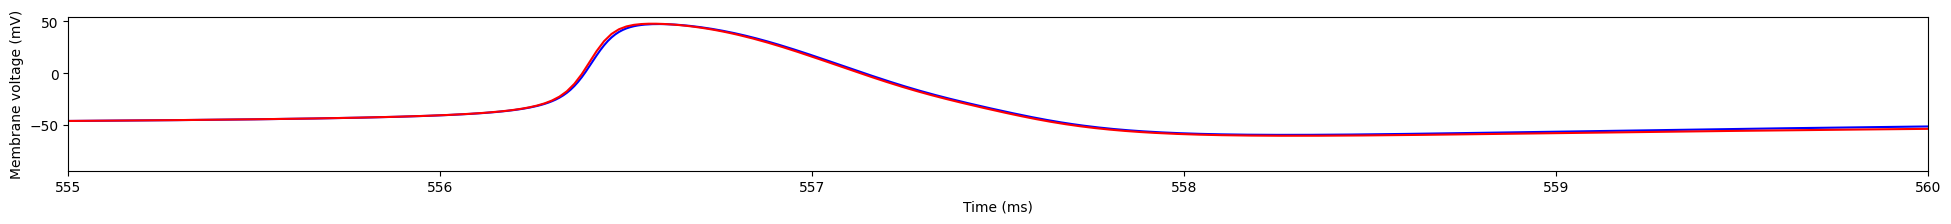

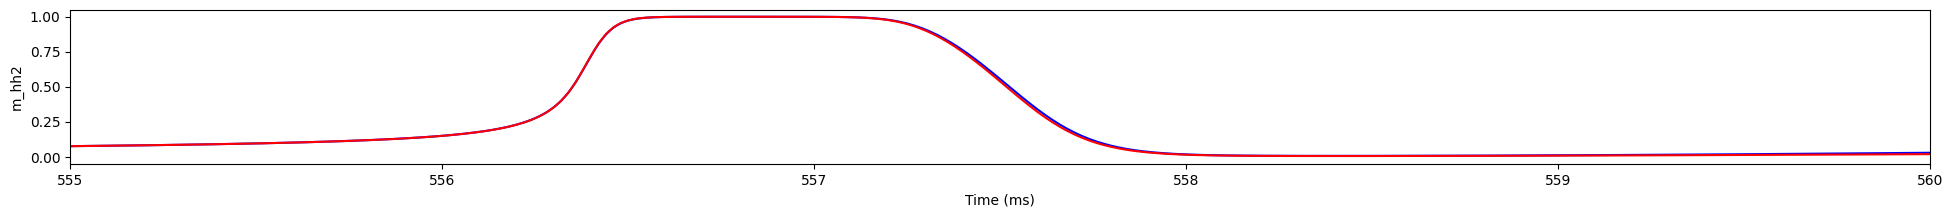

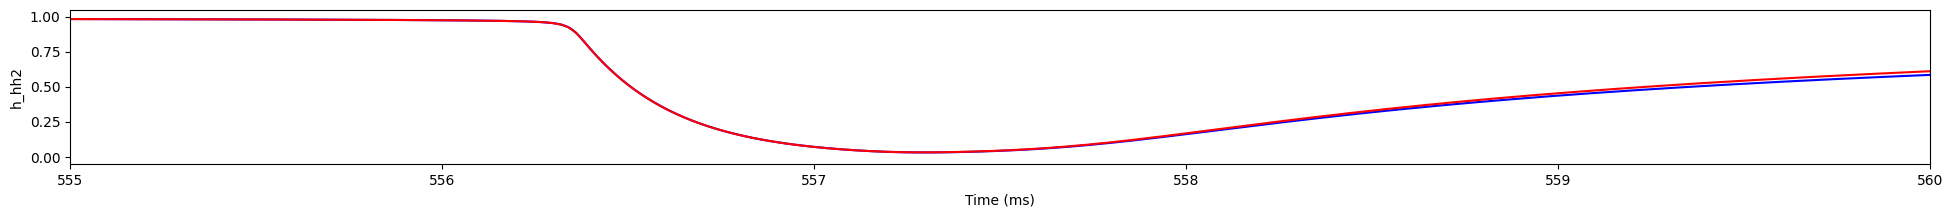

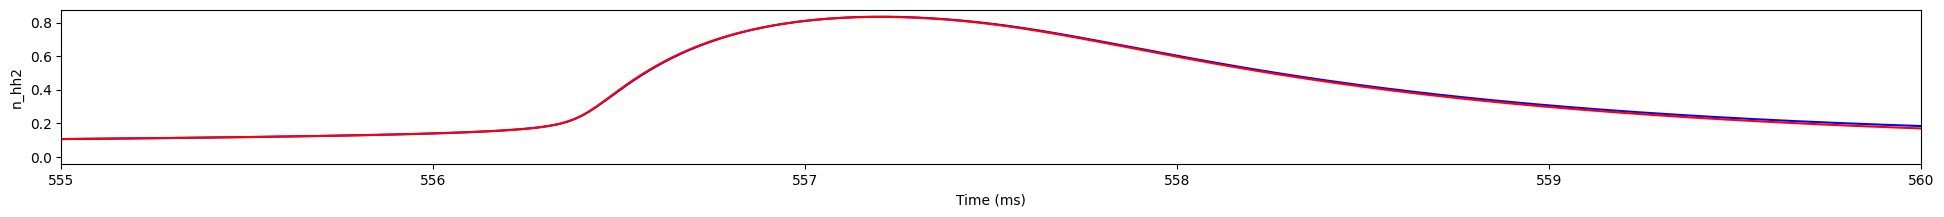

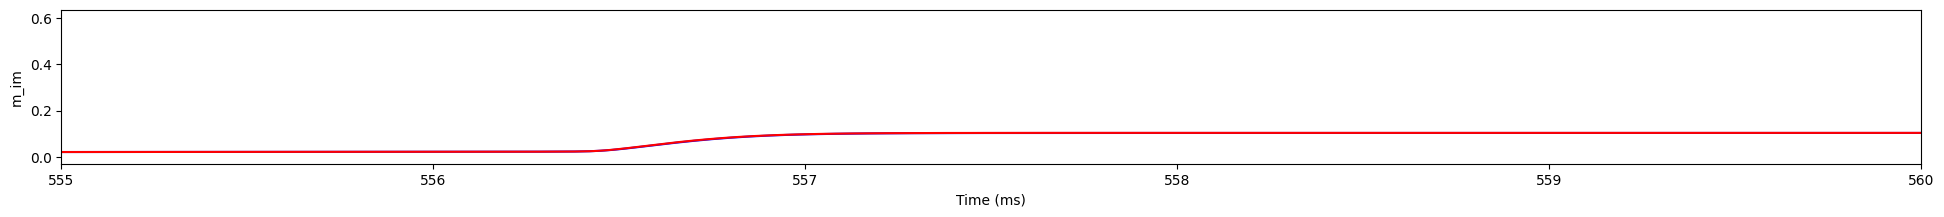

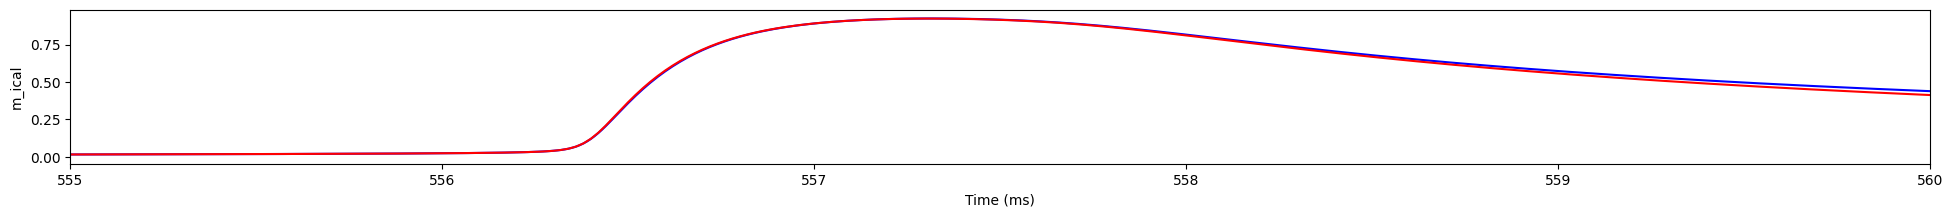

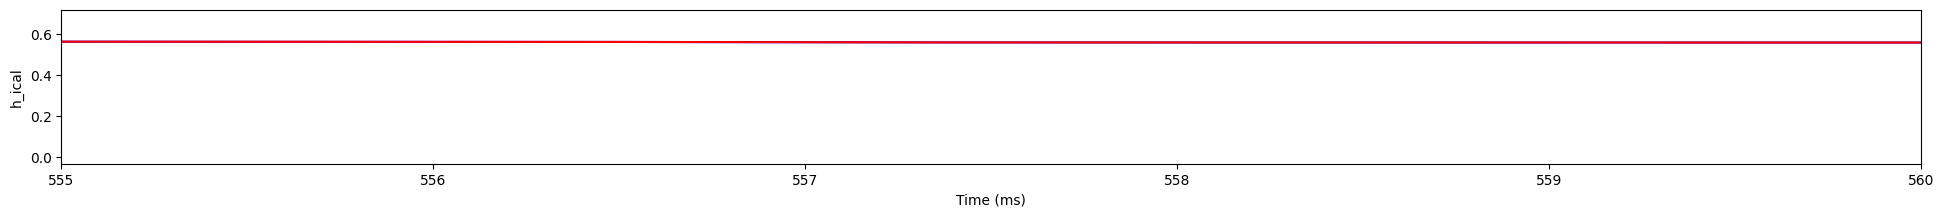

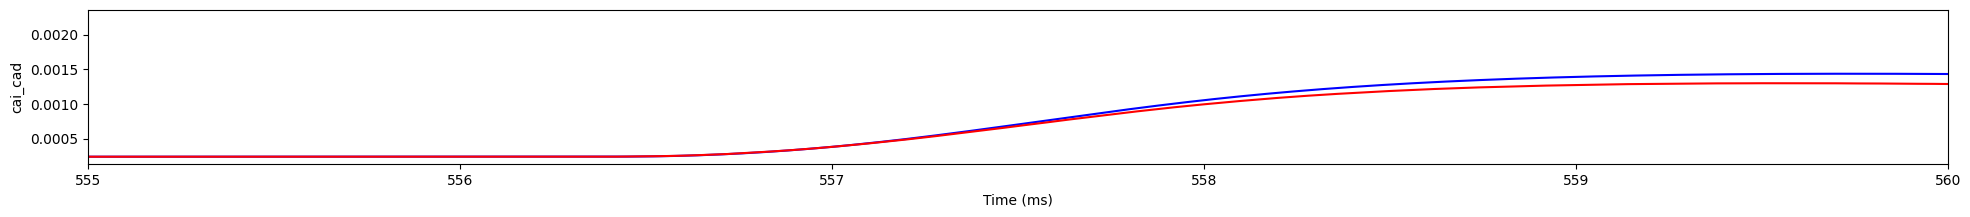

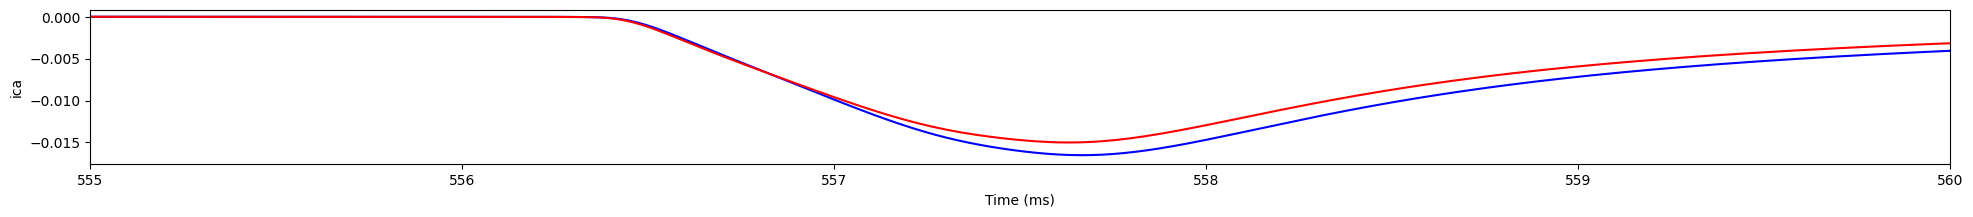

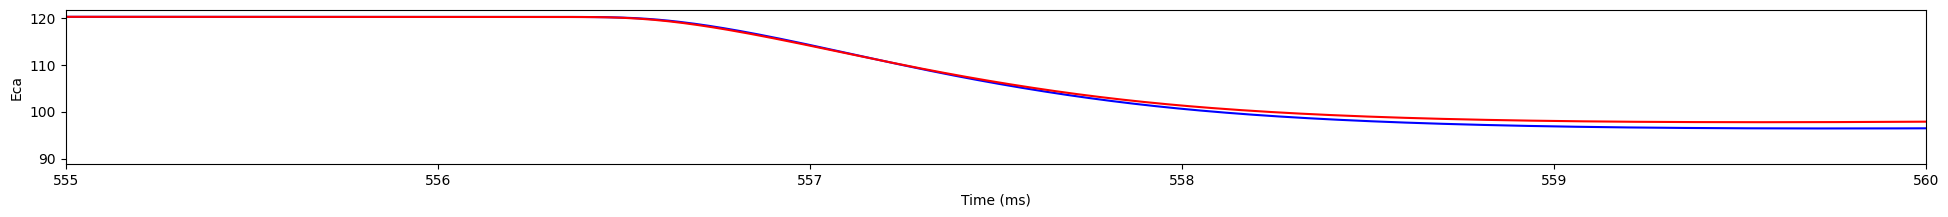

In [20]:
xinitial = 555
xfinal = 560

# xinitial = 0
# xfinal = 3000

# xinitial = 500
# xfinal = 1000

plot_data(time, voltage, ylabel='Membrane voltage (mV)', xyaxis=[xinitial, xfinal, -90, 50] , constant=1)
plot_data(time, mthh2, ylabel='m_hh2', xyaxis=[xinitial, xfinal, 0, 1] , constant=2)
plot_data(time, hthh2, ylabel='h_hh2', xyaxis=[xinitial, xfinal, 0, 1] , constant=3)
plot_data(time, nthh2, ylabel='n_hh2', xyaxis=[xinitial, xfinal, 0, 1] , constant=4)
plot_data(time, mtim, ylabel='m_im', xyaxis=[xinitial, xfinal, 0, 1] , constant=5)
plot_data(time, mtical, ylabel='m_ical', xyaxis=[xinitial, xfinal, 0, 1] , constant=6)
plot_data(time, htical, ylabel='h_ical', xyaxis=[xinitial, xfinal, 0.6, 0.8] , constant=7)
plot_data(time, caitcad, ylabel='cai_cad', xyaxis=[xinitial, xfinal, 0.0002, 0.004] , constant=8)
plot_data(time, icatcad, ylabel='ica', xyaxis=[xinitial, xfinal, -0.02, 0.0001] , constant=11)
plot_data(time, ecatcad, ylabel='Eca', xyaxis=[xinitial, xfinal, 80, 125.0] , constant=10)


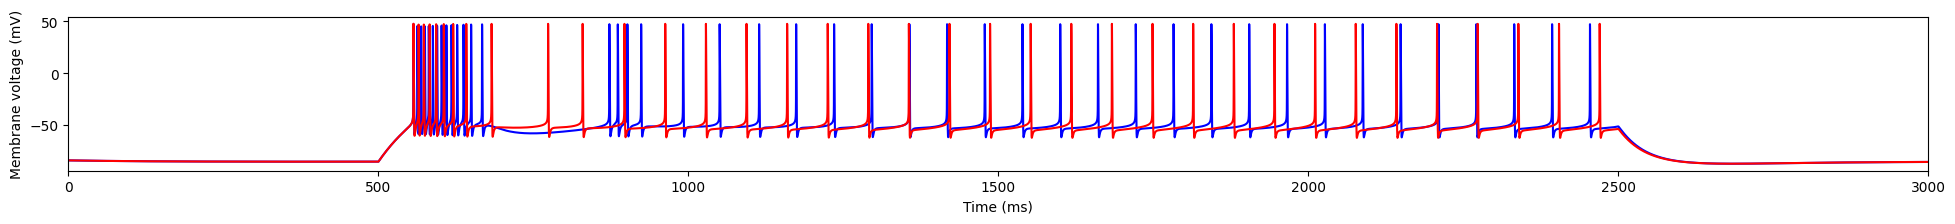

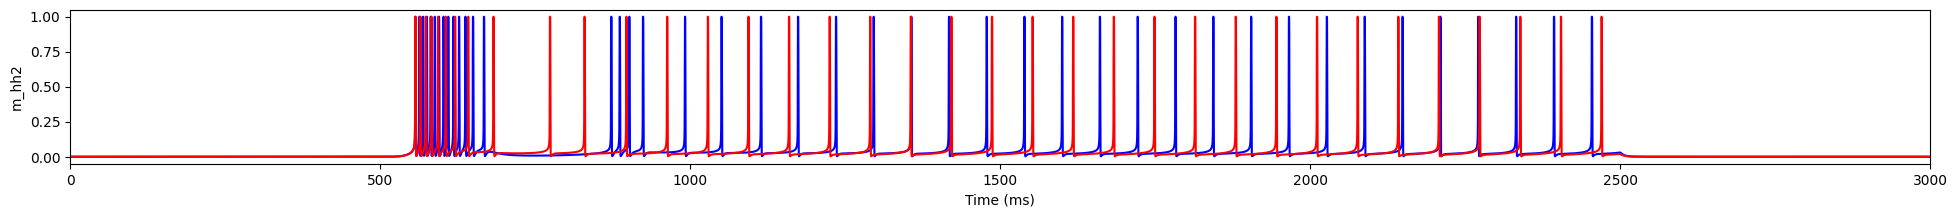

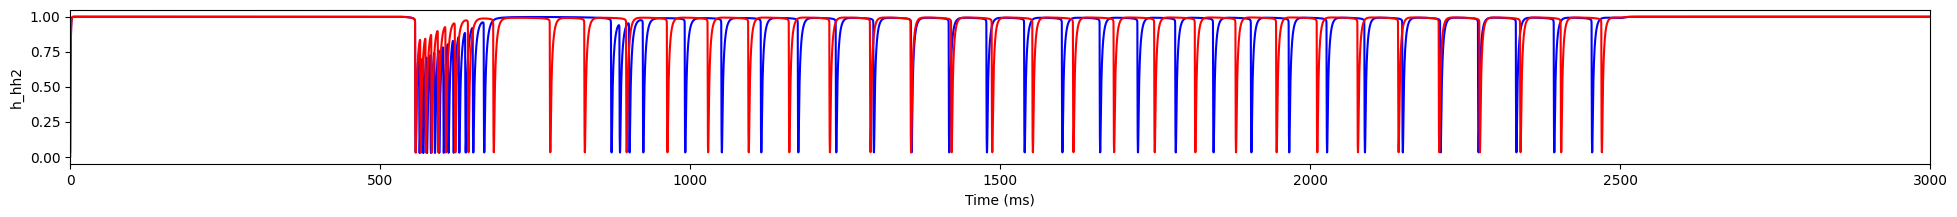

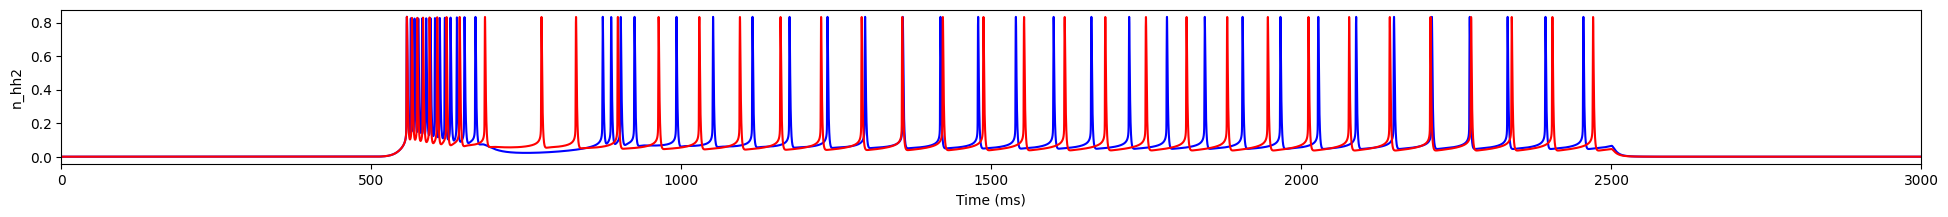

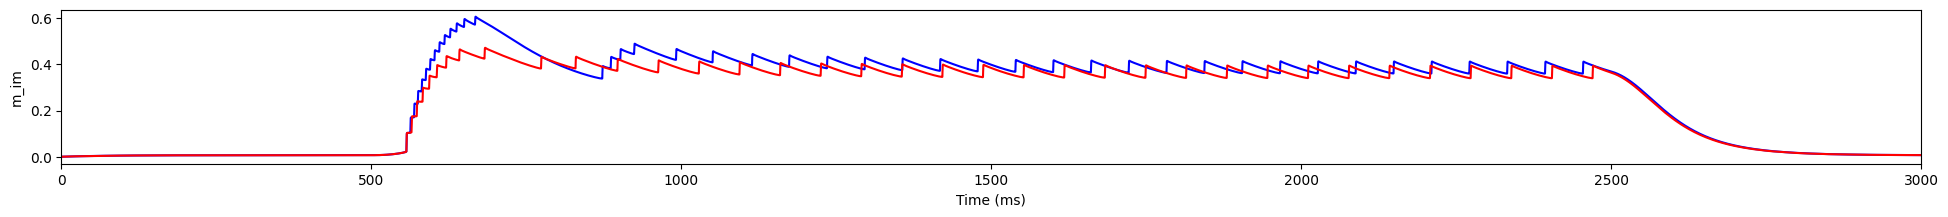

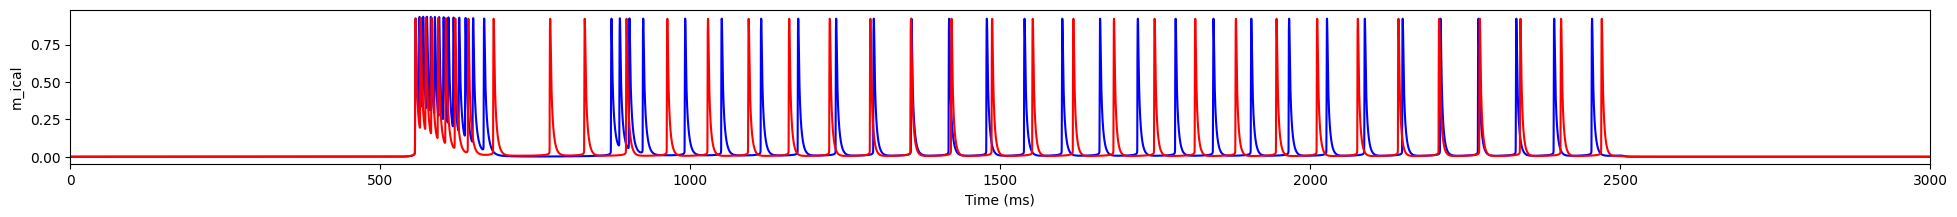

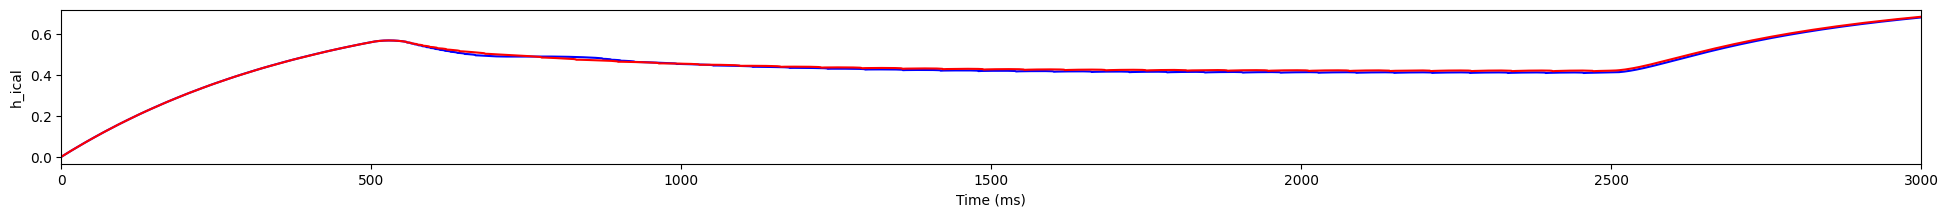

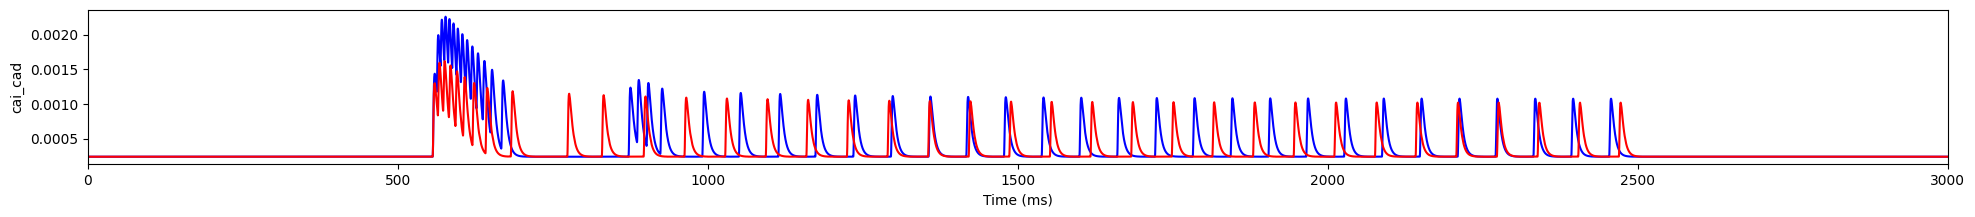

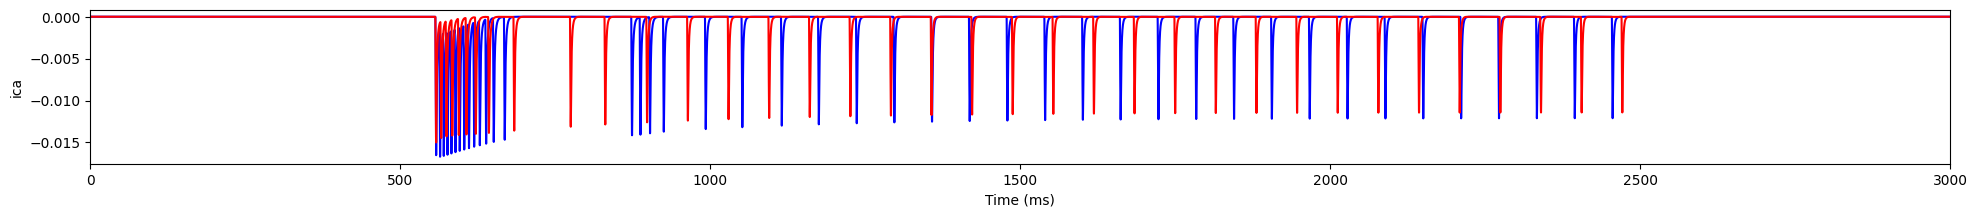

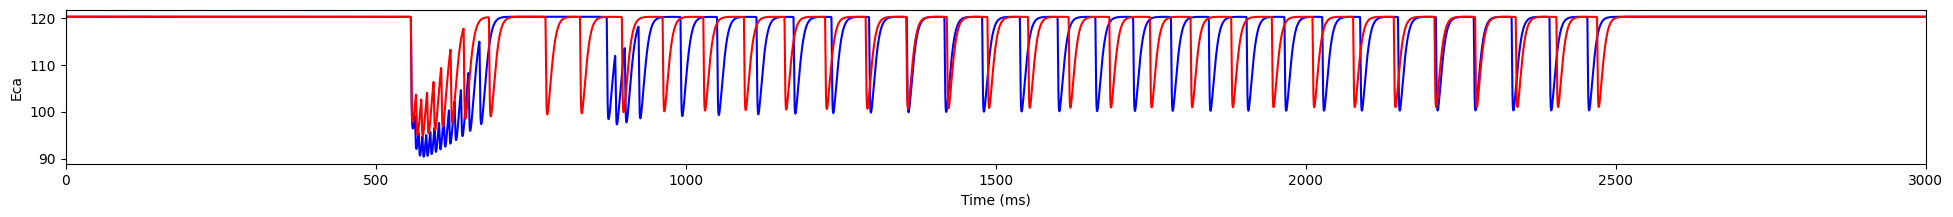

In [21]:
xinitial = 555
xfinal = 560

xinitial = 0
xfinal = 3000

# xinitial = 500
# xfinal = 1000

plot_data(time, voltage, ylabel='Membrane voltage (mV)', xyaxis=[xinitial, xfinal, -90, 50] , constant=1)
plot_data(time, mthh2, ylabel='m_hh2', xyaxis=[xinitial, xfinal, 0, 1] , constant=2)
plot_data(time, hthh2, ylabel='h_hh2', xyaxis=[xinitial, xfinal, 0, 1] , constant=3)
plot_data(time, nthh2, ylabel='n_hh2', xyaxis=[xinitial, xfinal, 0, 1] , constant=4)
plot_data(time, mtim, ylabel='m_im', xyaxis=[xinitial, xfinal, 0, 1] , constant=5)
plot_data(time, mtical, ylabel='m_ical', xyaxis=[xinitial, xfinal, 0, 1] , constant=6)
plot_data(time, htical, ylabel='h_ical', xyaxis=[xinitial, xfinal, 0.6, 0.8] , constant=7)
plot_data(time, caitcad, ylabel='cai_cad', xyaxis=[xinitial, xfinal, 0.0002, 0.004] , constant=8)
plot_data(time, icatcad, ylabel='ica', xyaxis=[xinitial, xfinal, -0.02, 0.0001] , constant=11)
plot_data(time, ecatcad, ylabel='Eca', xyaxis=[xinitial, xfinal, 80, 125.0] , constant=10)


In [22]:
print(soma.eca)
print(soma.ica)
print(soma.cai)
print(soma.v)
print(soma.m_ical)
print(soma.h_ical)

120.25540343330121
-4.41975331301585e-15
0.00024000000000113836
-85.51213578794874
3.789104005869191e-07
0.6800374023706726


In [23]:
soma.eca/np.log(2.0/soma.cai)

13.320242889960909

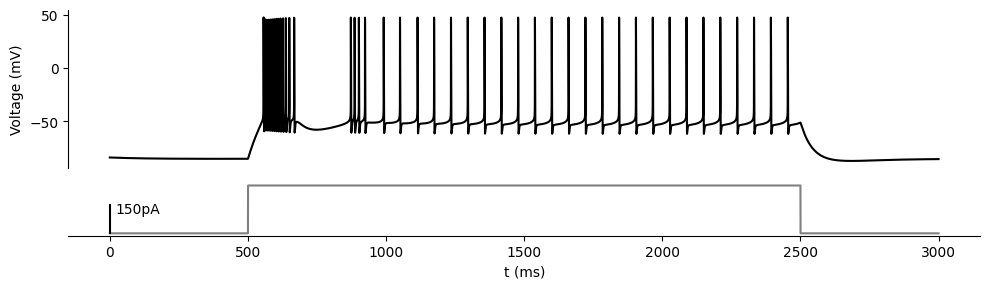

In [24]:
f, (ax0, ax1) = plt.subplots(2,1, figsize=(10,3), gridspec_kw = {'height_ratios':[3, 1]})
ax0.plot(time,voltage, 'k')
ax1.plot(time,stim_current, 'gray')

ax0.set_ylabel('Voltage (mV)')
ax0.spines['right'].set_visible(False)
ax0.spines['top'].set_visible(False)
ax0.spines['bottom'].set_visible(False)
ax0.get_xaxis().set_visible(False)


ax1.plot([0,0],[0,0.15],'k')
ax1.text(20,0.125,'150pA',va='center')
ax1.set_ylabel('I (nA)')
ax1.set_xlabel('t (ms)')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.get_yaxis().set_visible(False)
plt.tight_layout()